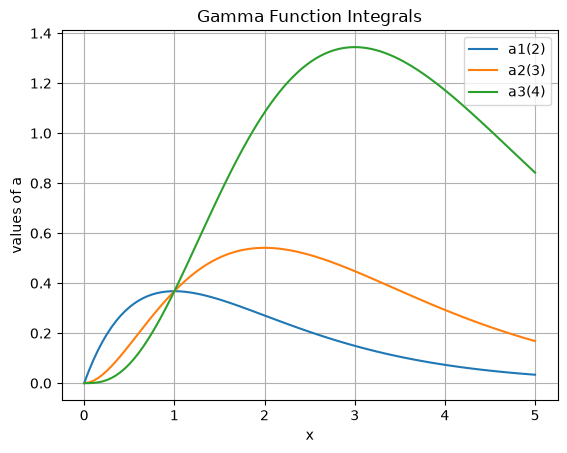

In [7]:
# a
import numpy as np
import pylab as plt

def integrand(x,a):
    return x**(a-1) * np.exp(-x)

# lists
a1_list =[]
a2_list = []
a3_list = []

# values of a
a1 = 2
a2 = 3
a3 = 4


x_values = np.linspace(0,5,100)

for x in x_values:
    a1_list.append(integrand(x,a1))
    a2_list.append(integrand(x,a2))
    a3_list.append(integrand(x,a3))

#graph
plt.plot(x_values,a1_list,label='a1(2)')
plt.plot(x_values,a2_list,label='a2(3)')
plt.plot(x_values,a3_list,label='a3(4)')
plt.xlabel('x')
plt.ylabel('values of a')
plt.title('Gamma Function Integrals')
plt.legend()
plt.grid(True)
plt.show()




In [8]:
# b

"""
f(x) = x**(a-1) * e**(-x)

f'(x) = d/dx (x**(a-1) * e**(-x)) = 0

Product rule: 
(uv)' = u'v + uv'

f'(x) = ((a-1) * x**(a-2)) * e**(-x) + x**(a-1) * (-e**(-x)) = 0

f'(x) = (a-1) * x**(a-2) * e**(-x) - x**(a-1) * e**(-x) = 0

Factor out the common terms x**(a-2) * e**(-x):
x**(a-2) * e**(-x) * [(a-1) - x] = 0

Since x**(a-2) * e**(-x) != 0 for x > 0:
(a-1) - x = 0

x = a - 1
"""

"\nf(x) = x**(a-1) * e**(-x)\n\nf'(x) = d/dx (x**(a-1) * e**(-x)) = 0\n\nProduct rule: \n(uv)' = u'v + uv'\n\nf'(x) = ((a-1) * x**(a-2)) * e**(-x) + x**(a-1) * (-e**(-x)) = 0\n\nf'(x) = (a-1) * x**(a-2) * e**(-x) - x**(a-1) * e**(-x) = 0\n\nFactor out the common terms x**(a-2) * e**(-x):\nx**(a-2) * e**(-x) * [(a-1) - x] = 0\n\nSince x**(a-2) * e**(-x) != 0 for x > 0:\n(a-1) - x = 0\n\nx = a - 1\n"

In [ ]:
# c
"""
Given change of variables:
z = x / (c + x)

1) For what value of x does z = 1/2?
1/2 = x / (c + x)
c + x = 2x
x = c

2) Appropriate choice of parameter c to put the peak at z = 1/2:
From part (b), we know that the peak occurs at:
x = a - 1

Since the peak must occur at z = 1/2, and we found that z = 1/2 corresponds to x = c:
c = a - 1
"""

In [ ]:
# d

"""

1) Derivation:
Original integrand: f(x) = x**(a-1) * e**(-x)

Using the identity: x**(a-1) = e**((a-1) * ln(x))
Substitute this into the integrand:
f(x) = e**((a-1) * ln(x)) * e**(-x)

Combine the exponents using e**A * e**B = e**(A + B):
f(x) = e**((a-1) * ln(x) - x)

2) Why the new expression is better:
- In the old expression, for large values of x or a, x**(a-1) grows extremely fast 
  causing numerical overflow (inf), while e**(-x) drops quickly causing underflow (0). 
  Multiplying them results in an undefined "inf * 0" or NaN error.
  
- In the new expression, the subtraction ((a-1)*ln(x) - x) happens INSIDE the exponent 
  BEFORE evaluating the exponential function. Since ln(x) grows very slowly, the 
  exponent stays within a moderate, safe range, completely preventing intermediate 
  overflow and underflow issues.
"""

In [10]:
# e
import numpy as np

# function
def integrand(z,a):
    c = a-1
    x = z*c/(1-z)
    return np.exp((a-1)*np.log(x)-x) * (c/(1-z)**2)


# integral
def gamma(a):
    N = 50
    z_min = 0.0
    z_max = 1.0
    x_standard, w_standard = np.polynomial.legendre.leggauss(N)
    # mapping
    xp = 0.5 * (z_max-z_min) * x_standard + 0.5 * (z_max+z_min)
    wp = 0.5 * (z_max-z_min) * w_standard
    integral_result = sum(wp*(integrand(xp,a)))
    return integral_result
print(gamma(3/2))

0.8862272081548237


In [12]:
# f

""" 
for integer number:
gamma(a) = (a-1)!

"""

print(gamma(3)) # 2!
print(gamma(6)) # 5!
print(gamma(10)) # 9!



2.000000000000059
119.99999999999955
362879.9999999985
